# Import Important libraries 

In [1]:
import pandas as pd
import  numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px 


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression , LogisticRegression 
from sklearn.svm import SVR 


from sklearn.preprocessing import StandardScaler 
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import mean_absolute_error 

# why MSE 

# Load data 

In [2]:
data=pd.read_csv('/kaggle/input/calories-burnt-prediction/calories.csv')
data

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/calories-burnt-prediction/calories.csv'

# Explore data 

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


In [ ]:
data.describe() 

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,15000.0000,15000.0000,15000.0000,15000.0000,15000.0000,15000.0000,15000.0000,15000.0000
mean,14977358.5385,42.7898,174.4651,74.9669,15.5306,95.5185,40.0255,89.5395
std,2872851.4522,16.9803,14.2581,15.0357,8.3192,9.5833,0.7792,62.4570
min,10001159.0000,20.0000,123.0000,36.0000,1.0000,67.0000,37.1000,1.0000
25%,12474190.7500,28.0000,164.0000,63.0000,8.0000,88.0000,39.6000,35.0000
50%,14997285.0000,39.0000,175.0000,74.0000,16.0000,96.0000,40.2000,79.0000
75%,17449278.7500,56.0000,185.0000,87.0000,23.0000,103.0000,40.6000,138.0000
max,19999647.0000,79.0000,222.0000,132.0000,30.0000,128.0000,41.5000,314.0000


<Axes: >

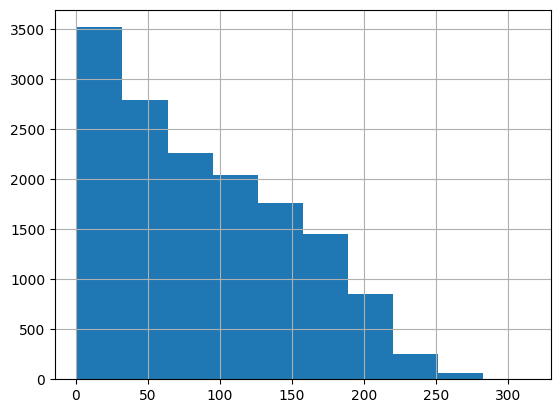

In [ ]:
data.Calories.hist()

In [ ]:
data.describe(include='O')

,Gender
count,15000
unique,2
top,female
freq,7553


In [ ]:
data.columns=data.columns.str.lower()

In [ ]:
data.duplicated().sum()

0

In [ ]:
data.duplicated(subset='user_id').sum()

0

In [ ]:
data.gender.value_counts(normalize=True).mul(100).round(2)

gender
female    50.35
male      49.65
Name: proportion, dtype: float64

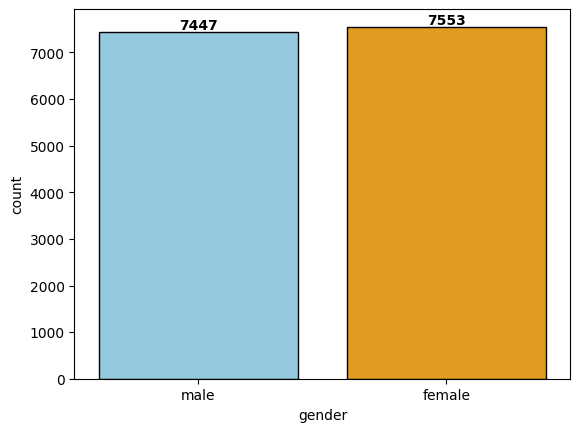

In [ ]:
ax=sns.countplot(data=data,x='gender',palette=['skyblue','orange'],edgecolor='black')
for i in ax.containers:
    ax.bar_label(i,fontsize=10,fontweight='bold')


In [ ]:
for i in data.select_dtypes(include='number'):
    if i !='user_id':
        fig=px.histogram(data,data[i],color_discrete_sequence=['skyblue','orange'],title=i,color='gender')
        fig.show()

# EDA

In [ ]:
data.columns

Index(['user_id', 'gender', 'age', 'height', 'weight', 'duration',
       'heart_rate', 'body_temp', 'calories'],
      dtype='object')

In [ ]:
data.groupby('gender').median()

,user_id,age,height,weight,duration,heart_rate,body_temp,calories
gender,,,,,,,,
female,14986208.0,40.0,164.0,63.0,16.0,95.0,40.2,80.0
male,15006801.0,39.0,185.0,87.0,15.0,96.0,40.2,78.0


In [ ]:
pd.set_option('display.float_format', '{:.4f}'.format)
data.groupby('gender').mean().T

gender,female,male
user_id,14979317.4464,14975371.7475
age,42.7355,42.8449
height,164.4059,184.6675
weight,63.2745,86.8257
duration,15.5022,15.5594
heart_rate,95.4086,95.6301
body_temp,40.0198,40.0312
calories,88.1531,90.9457


In [ ]:
data_gender=data.groupby('gender').median().T
data_gender

gender,female,male
user_id,14986208.0000,15006801.0000
age,40.0000,39.0000
height,164.0000,185.0000
weight,63.0000,87.0000
duration,16.0000,15.0000
heart_rate,95.0000,96.0000
body_temp,40.2000,40.2000
calories,80.0000,78.0000


In [ ]:
data_gender=data.groupby('gender').median()
data_gender

,user_id,age,height,weight,duration,heart_rate,body_temp,calories
gender,,,,,,,,
female,14986208.0000,40.0000,164.0000,63.0000,16.0000,95.0000,40.2000,80.0000
male,15006801.0000,39.0000,185.0000,87.0000,15.0000,96.0000,40.2000,78.0000


In [ ]:
data.columns

Index(['age', 'height', 'weight', 'duration', 'heart_rate', 'body_temp',
       'calories', 'data_gen_encode', 'bmi', 'heart_rate_duration',
       'cal_duration'],
      dtype='object')

In [ ]:
fig=px.scatter(data,x='duration',y='calories')
fig.show()

In [ ]:
fig=px.scatter(data,x='heart_rate',y='calories')
fig.show()

In [ ]:
fig=px.scatter(data,x='body_temp',y='calories')
fig.show()

In [ ]:
fig=px.scatter(data,x='age',y='calories')
fig.show()

In [ ]:
fig=px.scatter(data,x='height',y='calories')
fig.show()

In [ ]:
fig=px.scatter(data,x='weight',y='calories')
fig.show()

In [ ]:
fig=px.scatter(data,x='height',y='weight',size='calories',color='gender')
fig.show()

In [ ]:
data['data_gen_encode']=pd.get_dummies(data['gender'],drop_first=True).astype('int')

In [ ]:
# male--> 1 female--> 0

In [ ]:
data.drop(columns=['user_id','gender'],inplace=True)

In [ ]:
data

,age,height,weight,duration,heart_rate,body_temp,calories,data_gen_encode
0,68,190.0,94.0,29.0,105.0,40.8,231.0,1
1,20,166.0,60.0,14.0,94.0,40.3,66.0,0
2,69,179.0,79.0,5.0,88.0,38.7,26.0,1
3,34,179.0,71.0,13.0,100.0,40.5,71.0,0
4,27,154.0,58.0,10.0,81.0,39.8,35.0,0
...,...,...,...,...,...,...,...,...
14995,20,193.0,86.0,11.0,92.0,40.4,45.0,0
14996,27,165.0,65.0,6.0,85.0,39.2,23.0,0
14997,43,159.0,58.0,16.0,90.0,40.1,75.0,0
14998,78,193.0,97.0,2.0,84.0,38.3,11.0,1


In [ ]:
fig=px.imshow(data.corr(),color_continuous_scale='Blues',text_auto=True)
fig.show()

In [ ]:
data['bmi']=data.weight/(data.height/100)**2
data

,age,height,weight,duration,heart_rate,body_temp,calories,data_gen_encode,bmi
0,68,190.0,94.0,29.0,105.0,40.8,231.0,1,26.038781
1,20,166.0,60.0,14.0,94.0,40.3,66.0,0,21.773842
2,69,179.0,79.0,5.0,88.0,38.7,26.0,1,24.655910
3,34,179.0,71.0,13.0,100.0,40.5,71.0,0,22.159109
4,27,154.0,58.0,10.0,81.0,39.8,35.0,0,24.456063
...,...,...,...,...,...,...,...,...,...
14995,20,193.0,86.0,11.0,92.0,40.4,45.0,0,23.087868
14996,27,165.0,65.0,6.0,85.0,39.2,23.0,0,23.875115
14997,43,159.0,58.0,16.0,90.0,40.1,75.0,0,22.942130
14998,78,193.0,97.0,2.0,84.0,38.3,11.0,1,26.040968


In [ ]:
data["heart_rate_duration"] = data["heart_rate"] * data["duration"]


In [ ]:
data['cal_duration']=data["calories"] * data["duration"]

In [ ]:
fig=px.imshow(data.corr(),color_continuous_scale='Blues',text_auto=True)
fig.show()

In [ ]:
data_corr=data.corr()['calories']
data_corr

age                    0.154395
height                 0.017537
weight                 0.035481
duration               0.955421
heart_rate             0.897882
body_temp              0.824558
calories               1.000000
data_gen_encode        0.022357
bmi                    0.056473
heart_rate_duration    0.974597
cal_duration           0.979707
Name: calories, dtype: float64

In [ ]:
high_corr=data_corr[(data.corr()['calories']>0.15)==True]
high_corr.index

Index(['age', 'duration', 'heart_rate', 'body_temp', 'calories',
       'heart_rate_duration', 'cal_duration'],
      dtype='object')

In [ ]:
x=data.drop(columns='calories',axis=1)
y=data.calories

In [ ]:
mt=mutual_info_regression(x,y,random_state=42)
mt

array([3.17683990e-02, 4.46330992e-03, 1.96382413e-02, 1.51214424e+00,
       8.66499610e-01, 9.95855811e-01, 1.48440683e-02, 0.00000000e+00,
       1.79948265e+00, 4.73171684e+00])

In [ ]:
mi_scores = pd.Series(mt, index=x.columns)
mutual_score_sort=mi_scores.sort_values()

In [ ]:
fig=px.bar(mutual_score_sort,x=mutual_score_sort.values,y=mutual_score_sort.index)
fig.show()

# Split data 

In [ ]:
x=data[['age', 'duration', 'heart_rate', 'body_temp', 'heart_rate_duration', 'cal_duration']]
y=data['calories']

# Split data into train and test

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


# Scale data

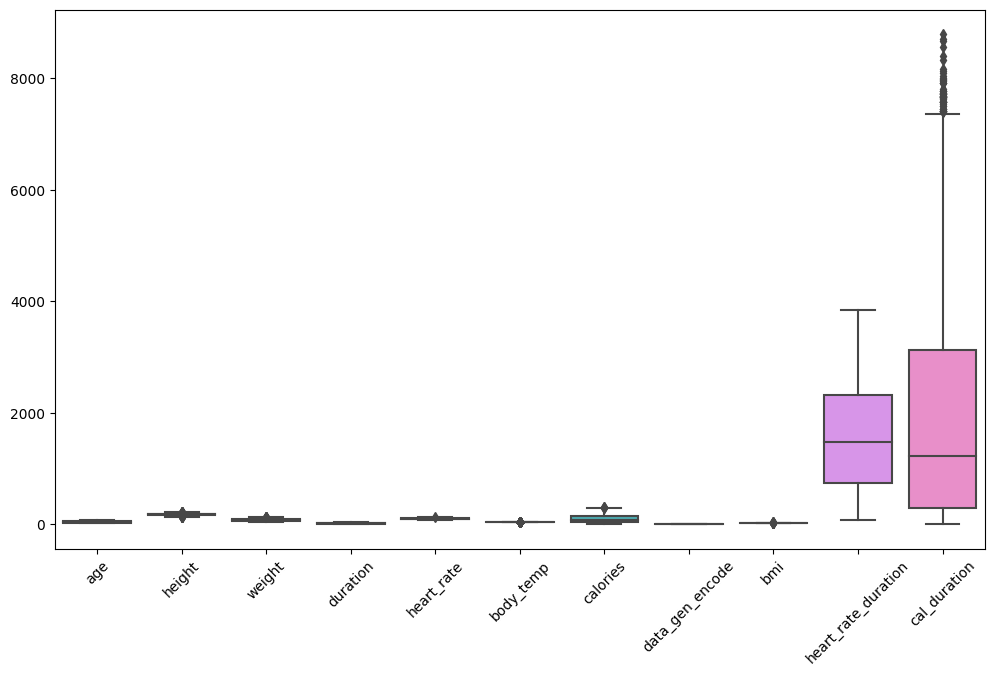

In [ ]:
plt.figure(figsize=(12,7))
sns.boxplot(data)
plt.xticks(rotation=45)
plt.show()

In [ ]:
scale=StandardScaler()
x_train=scale.fit_transform(x_train)
x_test=scale.transform(x_test)

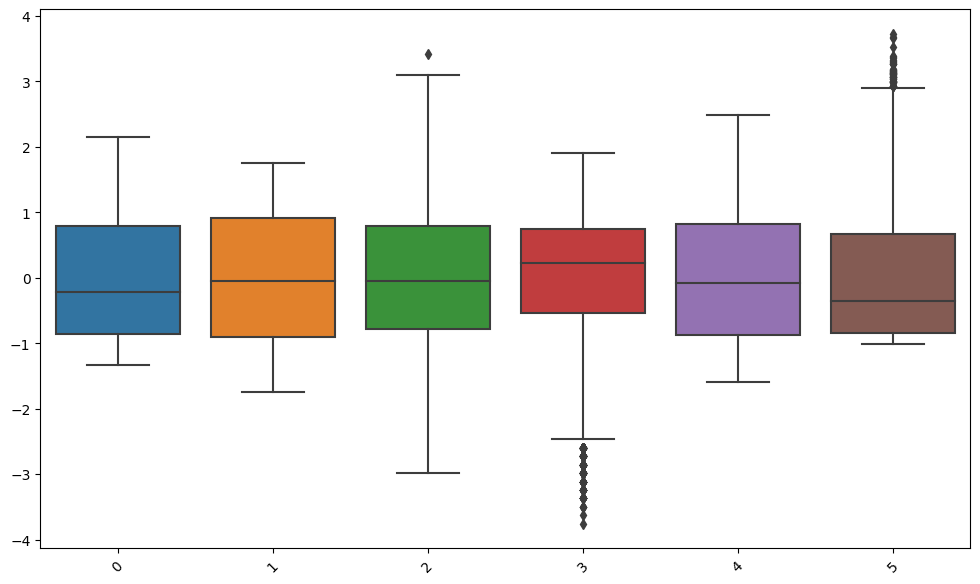

In [ ]:
plt.figure(figsize=(12,7))
sns.boxplot(x_train)
plt.xticks(rotation=45)
plt.show()

# build model

In [ ]:
lr_reg=LinearRegression()
lr_reg.fit(x_train,y_train)

LinearRegression()

In [ ]:
lr_reg.score(x_train,y_train)

0.9917916536309653

In [ ]:
lr_reg.score(x_test,y_test)

0.9922876427295277

In [ ]:
y_pred=lr_reg.predict(x_test)
y_pred

array([173.14530368, 192.82471363,  55.33849343, ..., 115.53491365,
        18.14291842, 217.79258955])

In [ ]:
mean_absolute_error(y_pred,y_test)

4.330748747431325

In [ ]:
print(lr_reg.coef_)
print(lr_reg.intercept_)

[  5.0468827   25.17875345  14.0273819    3.916518   -18.22882109
  39.59884189]
89.0954166666667


In [ ]:
feat_sore=pd.DataFrame({'features':x.columns,
                       'importance':lr_reg.coef_})

In [ ]:
feat_sort=feat_sore.sort_values(by='importance')
fig=px.bar(feat_sort,x='features',y='importance')
fig.show()

In [ ]:
svr=SVR()
svr.fit(x_train,y_train)

SVR()

In [ ]:
print(svr.score(x_train,y_train))
print(svr.score(x_test,y_test))

0.9941258342796364
0.9944148302747544


In [ ]:
y_pred=svr.predict(x_test)
y_pred

array([174.40563065, 184.47514355,  53.71338429, ..., 120.74356269,
        17.69764189, 201.00173718])

In [ ]:
mean_absolute_error(y_pred,y_test)

2.6663429761944606